In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("train.csv")

In [3]:
test = pd.read_csv("test.csv")

In [4]:
train.head()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0


In [5]:
train.shape

(192, 24)

In [6]:
test.shape

(48, 24)

In [7]:
train.dtypes

version                              int64
team                                object
continent                           object
is_host                              int64
goals_scored_last_4y                 int64
goals_received_last_4y               int64
wins_last_4y                         int64
losses_last_4y                       int64
draws_last_4y                        int64
world_cup_titles_before              int64
squad_total_market_value_eur       float64
fifa_rank_pre_tournament             int64
fifa_points_pre_tournament         float64
squad_avg_age                      float64
world_cup_participations_before      int64
groups_passed_before                 int64
round16_before                       int64
quarterfinals_before                 int64
semifinals_before                    int64
finals_before                        int64
winner                               int64
finalist                             int64
semi_finalist                        int64
quarter_fin

In [8]:
train.describe()

,version,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
count,192.00000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,1.600000e+02,192.000000,...,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2012.00000,0.036458,84.583333,44.572917,26.046875,11.052083,11.802083,0.427083,3.433053e+08,23.541667,...,5.625000,3.572917,2.244792,2.223958,1.348958,0.697917,0.031250,0.062500,0.125000,0.250000
std,6.84916,0.187918,23.731776,13.608009,6.912534,4.745612,3.496055,1.085312,3.489032e+08,18.214497,...,5.548926,4.584848,2.701071,3.525056,2.618520,1.731263,0.174448,0.242694,0.331584,0.434145
min,2002.00000,0.000000,28.000000,19.000000,8.000000,2.000000,4.000000,0.000000,6.270000e+06,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.00000,0.000000,66.000000,35.000000,21.000000,8.000000,10.000000,0.000000,9.385750e+07,9.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2012.00000,0.000000,83.500000,42.500000,25.000000,10.500000,12.000000,0.000000,2.179400e+08,20.000000,...,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018.00000,0.000000,102.000000,53.250000,31.000000,14.000000,14.000000,0.000000,4.129750e+08,34.000000,...,10.000000,6.250000,4.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.250000
max,2022.00000,1.000000,156.000000,95.000000,48.000000,30.000000,23.000000,5.000000,1.620000e+09,105.000000,...,21.000000,19.000000,11.000000,16.000000,13.000000,8.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
train.isnull().sum()

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur       32
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                              0
finalist                            0
semi_finalist                       0
quarter_finalist                    0
dtype: int64

In [10]:
train.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

In [11]:
train= train.fillna(train.mean(numeric_only=True))

In [12]:
targets =['winner','finalist','semi_finalist','quarter_finalist']
for t in targets:
    print(f"{t}:{train[t].sum()}teams out of {len(train)}")

winner:6teams out of 192
finalist:12teams out of 192
semi_finalist:24teams out of 192
quarter_finalist:48teams out of 192


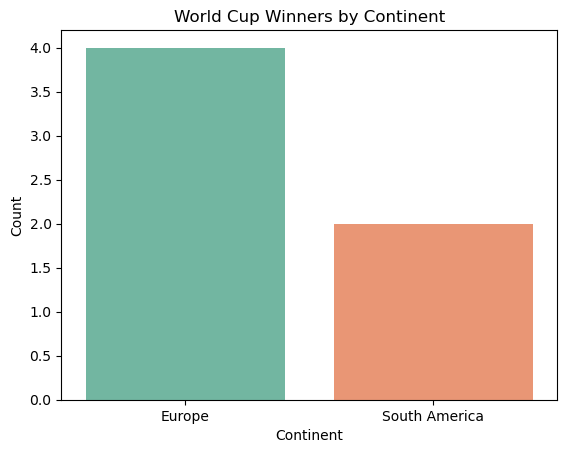

In [13]:
sns.countplot(data=train[train['winner']==1], x='continent', palette='Set2')
plt.title('World Cup Winners by Continent')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.show()

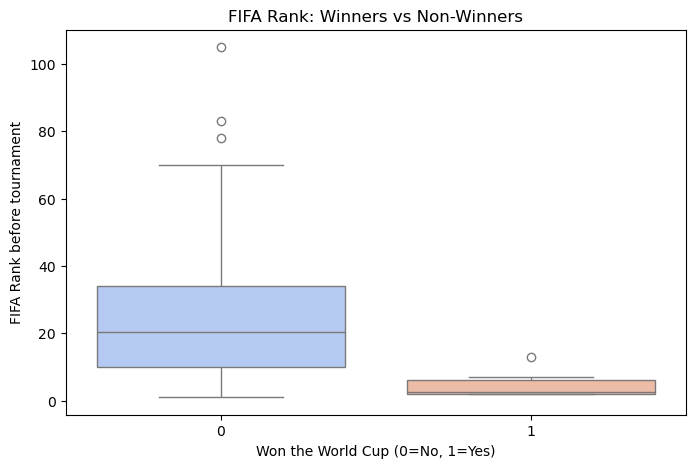

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='winner', y='fifa_rank_pre_tournament', palette='coolwarm')
plt.title('FIFA Rank: Winners vs Non-Winners')
plt.xlabel('Won the World Cup (0=No, 1=Yes)')
plt.ylabel('FIFA Rank before tournament')
plt.show()

In [ ]:
train = pd.get_dummies(train, columns=['continent'], prefix='cont', dtype=int)
test = pd.get_dummies(test, columns=['continent'], prefix='cont', dtype=int)

test = test.reindex(columns=train.columns, fill_value=0)

train.filter(like='cont').head()


,cont_Africa,cont_Asia,cont_Europe,cont_North America,cont_Oceania,cont_South America
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,1,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0


In [16]:
train.head()

,version,team,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,...,winner,finalist,semi_finalist,quarter_finalist,cont_Africa,cont_Asia,cont_Europe,cont_North America,cont_Oceania,cont_South America
0,2006,Angola,0,61,49,19,13,14,0,52700000.0,...,0,0,0,0,1,0,0,0,0,0
1,2006,Argentina,0,97,55,31,10,10,2,777200000.0,...,0,0,0,1,0,0,0,0,0,1
2,2006,Australia,0,101,34,23,8,5,0,48030000.0,...,0,0,0,0,0,0,0,0,1,0
3,2006,Brazil,0,117,47,30,9,17,5,858500000.0,...,0,0,0,1,0,0,0,0,0,1
4,2006,Costa Rica,0,89,84,26,25,11,0,18400000.0,...,0,0,0,0,0,0,0,1,0,0


In [17]:
total_games_train = train['wins_last_4y'] + train['losses_last_4y'] + train['draws_last_4y']
train['win_rate'] = train['wins_last_4y'] / total_games_train.replace(0, np.nan)
train['win_rate'] = train['win_rate'].fillna(0)

total_games_test = test['wins_last_4y'] + test['losses_last_4y'] + test['draws_last_4y']
test['win_rate'] = test['wins_last_4y'] / total_games_test.replace(0, np.nan)
test['win_rate'] = test['win_rate'].fillna(0)

train[['wins_last_4y','losses_last_4y','draws_last_4y','win_rate']].head()

,wins_last_4y,losses_last_4y,draws_last_4y,win_rate
0,19,13,14,0.413043
1,31,10,10,0.607843
2,23,8,5,0.638889
3,30,9,17,0.535714
4,26,25,11,0.419355


In [18]:
train['goal_ratio'] = train['goals_scored_last_4y'] / (train['goals_received_last_4y'] + 1)
test['goal_ratio'] = test['goals_scored_last_4y'] / (test['goals_received_last_4y'] + 1)

train[['goals_scored_last_4y','goals_received_last_4y','goal_ratio']].head()

,goals_scored_last_4y,goals_received_last_4y,goal_ratio
0,61,49,1.220000
1,97,55,1.732143
2,101,34,2.885714
3,117,47,2.437500
4,89,84,1.047059


In [19]:
train['history_depth'] = (train['groups_passed_before'] + train['round16_before']*2 +
                           train['quarterfinals_before']*3 + train['semifinals_before']*4 +
                           train['finals_before']*5 + train['world_cup_titles_before']*6)

test['history_depth'] = (test['groups_passed_before'] + test['round16_before']*2 +
                          test['quarterfinals_before']*3 + test['semifinals_before']*4 +
                          test['finals_before']*5 + test['world_cup_titles_before']*6)

train[['history_depth']].describe()

,history_depth
count,192.000000
mean,26.182292
std,43.888878
min,0.000000
25%,0.000000
50%,6.000000
75%,29.500000
max,202.000000


In [20]:
train['value_per_cap'] = train['squad_total_market_value_eur'] / (train['world_cup_participations_before'] + 1)
test['value_per_cap'] = test['squad_total_market_value_eur'] / (test['world_cup_participations_before'] + 1)

train[['squad_total_market_value_eur','world_cup_participations_before','value_per_cap']].head()

,squad_total_market_value_eur,world_cup_participations_before,value_per_cap
0,52700000.0,0,5.270000e+07
1,777200000.0,13,5.551429e+07
2,48030000.0,1,2.401500e+07
3,858500000.0,17,4.769444e+07
4,18400000.0,2,6.133333e+06


In [21]:
median_value = train['squad_total_market_value_eur'].median()

train['squad_total_market_value_eur'] = train['squad_total_market_value_eur'].fillna(median_value)
test['squad_total_market_value_eur'] = test['squad_total_market_value_eur'].fillna(median_value)

# Confirm no missing values left
print("Missing in train:", train.isnull().sum().sum())
print("Missing in test:", test.isnull().sum().sum())

Missing in train: 0
Missing in test: 192


In [22]:
feature_cols = [
    'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
    'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
    'world_cup_titles_before', 'squad_total_market_value_eur',
    'fifa_rank_pre_tournament', 'fifa_points_pre_tournament',
    'squad_avg_age', 'world_cup_participations_before',
    'groups_passed_before', 'round16_before', 'quarterfinals_before',
    'semifinals_before', 'finals_before',
    'win_rate', 'goal_ratio', 'history_depth', 'value_per_cap'
]

print("Missing in train features:", train[feature_cols].isnull().sum().sum())
print("Missing in test features:", test[feature_cols].isnull().sum().sum())

Missing in train features: 0
Missing in test features: 0


In [23]:
targets = ['winner', 'finalist', 'semi_finalist', 'quarter_finalist']

X_train = train[feature_cols]
X_test = test[feature_cols]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (192, 21)
X_test shape: (48, 21)


In [24]:
from xgboost import XGBClassifier

models = {}
cv_scores = {}

for target in targets:
    y = train[target]
    
    ratio = (y == 0).sum() / (y == 1).sum()
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        class_weight='balanced',
        random_state=42
    )
    cv = cross_val_score(model, X_train, y, cv=5, scoring='roc_auc')
    cv_scores[target] = cv.mean()
    
    model.fit(X_train, y)
    models[target] = model
    print(f"{target} — AUC: {cv.mean():.3f}")

winner — AUC: 0.845
finalist — AUC: 0.797
semi_finalist — AUC: 0.810
quarter_finalist — AUC: 0.796


In [25]:
results = {}

for target in targets:
    prob = models[target].predict_proba(X_test)[:, 1]
    results[target] = (prob * 100).round(1)

output = test[['team']].copy()
for target in targets:
    output[f'prob_{target}'] = results[target]

output = output.sort_values('prob_winner', ascending=False).reset_index(drop=True)
output.index += 1
output

,team,prob_winner,prob_finalist,prob_semi_finalist,prob_quarter_finalist
1,France,42.3,55.6,60.5,73.3
2,Spain,38.4,54.2,67.6,78.1
3,England,30.8,49.3,63.5,72.8
4,Netherlands,26.8,41.8,47.6,73.3
5,Argentina,25.2,38.2,42.5,78.6
6,Portugal,14.2,45.0,63.2,62.2
7,Belgium,12.9,26.4,35.1,56.3
8,Morocco,9.9,44.3,63.4,57.7
9,Uruguay,7.5,11.3,28.9,47.7
10,Algeria,5.6,8.3,37.0,34.4


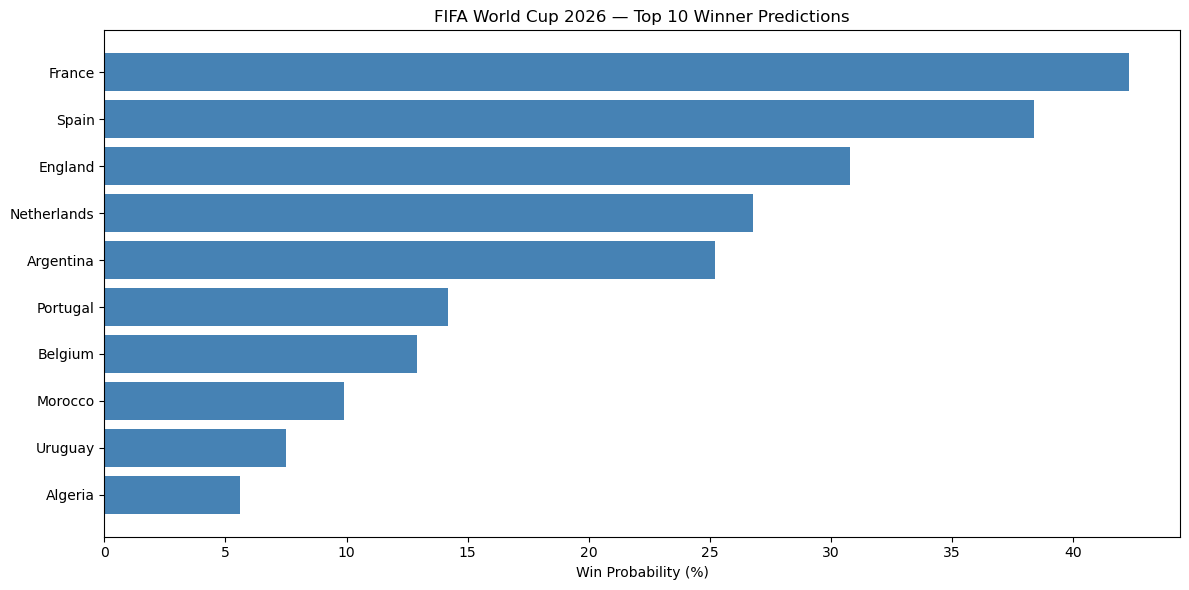

In [26]:
plt.figure(figsize=(12, 6))
plt.barh(output['team'][:10][::-1], output['prob_winner'][:10][::-1], color='steelblue')
plt.xlabel('Win Probability (%)')
plt.title('FIFA World Cup 2026 — Top 10 Winner Predictions')
plt.tight_layout()
plt.show()

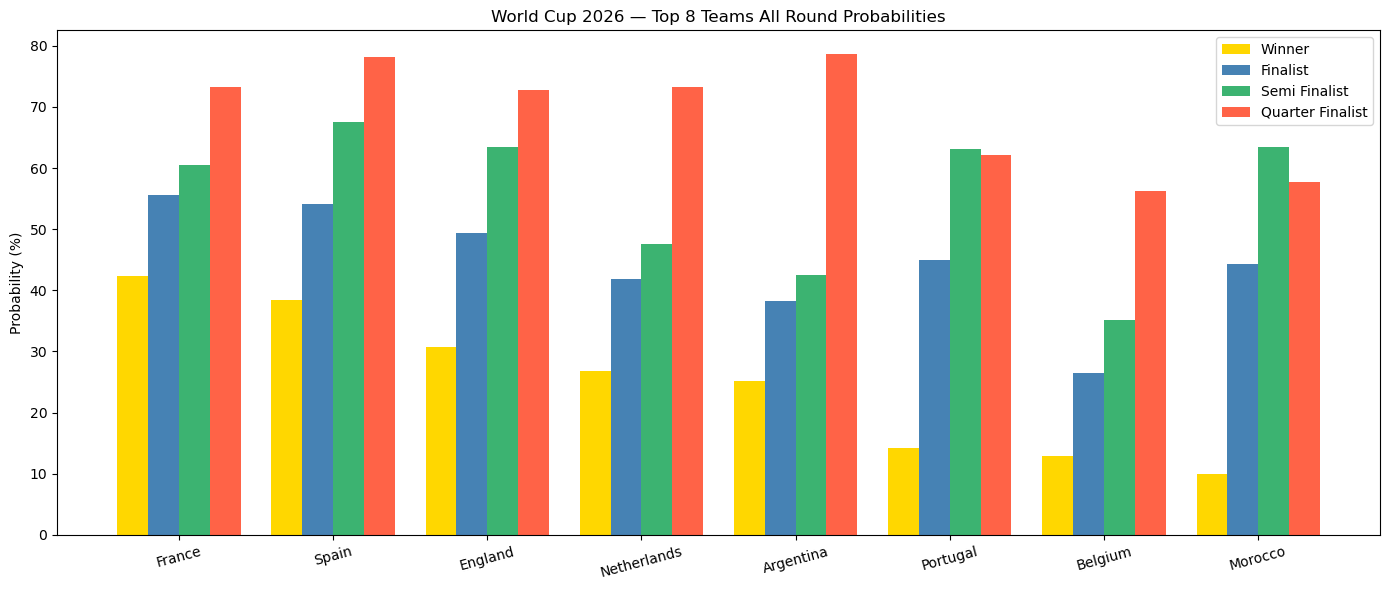

In [27]:
top8 = output.head(8)

x = np.arange(len(top8))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - 0.3, top8['prob_winner'],        width, label='Winner',           color='gold')
ax.bar(x - 0.1, top8['prob_finalist'],       width, label='Finalist',          color='steelblue')
ax.bar(x + 0.1, top8['prob_semi_finalist'],  width, label='Semi Finalist',     color='mediumseagreen')
ax.bar(x + 0.3, top8['prob_quarter_finalist'],width, label='Quarter Finalist', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(top8['team'], rotation=15)
ax.set_ylabel('Probability (%)')
ax.set_title('World Cup 2026 — Top 8 Teams All Round Probabilities')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
output.to_csv('wc2026_predictions.csv', index=True, index_label='rank')
print("Saved!")

Saved!
